# AFFC-Net + SUARA2: LC25000 Full Experiment Notebook (v5)
This notebook covers:
1. SUARA2 theoretical cost models and speedup analysis (corrected message size)
2. Training command reference (v5 script)
3. Results loading and full 5-metric comparison table
4. Allreduce speedup + epoch-time charts
5. Scale projection: measured P=2,4 to projected P=120 nodes


In [1]:
import os, sys, math, json, time
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

HOME = os.path.expanduser('~')

# Gradient message size for AFFC-Net (float32, all parameters)
# Updated automatically from results JSON after first training run.
MS_BYTES = 2_500_000   # ~2.5 MB estimate

print(f'Setup done. HOME = {HOME}')
print(f'Gradient message size: {MS_BYTES/1024:.1f} KB')


Setup done. HOME = /nfsshare/users/P126003189
Gradient message size: 2441.4 KB


## 1. SUARA2 Theoretical Cost Models


In [2]:
def T_linear(P, m, a, b, g): return (P-1) * (2*(a + b*m) + g*m)
def T_nono(P, m, a, b, g):   return 2*(P-1)*a + 2*b*m*math.log2(P) + g*m*(P-1)/P
def T_rd(P, m, a, b, g):     return math.log2(P)*(a + b*m + g*m) if P > 1 else 0.0
def T_rnos(P, m, a, b, g):   return 2*(P-1)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m
def T_rab(P, m, a, b, g):    return (2*math.log2(P)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m) if P > 1 else 0.0

ALGO_FUNCS = {'linear': T_linear, 'nono': T_nono, 'rd': T_rd, 'rnos': T_rnos, 'rab': T_rab}

# Hockney model parameters (Shaheen-II, from SUARA2 paper)
H_PARAMS = {
    'linear': (1.5e-6, 6.25e-11), 'nono': (1.5e-6, 6.25e-11),
    'rd'    : (1.2e-6, 7.0e-11),  'rnos': (1.4e-6, 6.5e-11),
    'rab'   : (1.3e-6, 6.8e-11),
}
GAMMA = 2e-10

def native_ring_time(P, m):
    '''Native allreduce using ring (Open MPI default for large messages)'''
    a, b = H_PARAMS['rnos']
    return T_rnos(P, m, a, b, GAMMA)

def suara2_optimal_time(P, m):
    '''SUARA2: best 2D grid, each sub-group picks its own optimal algorithm'''
    best_time = float('inf')
    best_Pc   = 1
    for Pc in range(1, P + 1):
        if P % Pc != 0:
            continue
        Pr = P // Pc
        t_row = min(f(Pc, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        t_col = min(f(Pr, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        ts = t_row + t_col
        if ts < best_time:
            best_time = ts
            best_Pc   = Pc
    return best_time, best_Pc

print('Allreduce models defined.')
print(f'Message size: {MS_BYTES/1e6:.2f} MB')


Allreduce models defined.
Message size: 2.50 MB


## 2. Theoretical Speedup Table


In [3]:
P_values = [2, 4, 8, 16, 32, 64, 120, 128, 256, 512, 1024]

speedup_vals  = []
t_native_vals = []
t_suara_vals  = []
Pc_vals       = []

print(f"{'P':>6}  {'T_native(ms)':>14}  {'T_SUARA2(ms)':>14}  {'Speedup':>9}  {'Pc*':>5}")
print('-' * 60)

for P in P_values:
    tn     = native_ring_time(P, MS_BYTES)
    ts, Pc = suara2_optimal_time(P, MS_BYTES)
    sp     = tn / ts if ts > 0 else 1.0
    speedup_vals.append(sp)
    t_native_vals.append(tn * 1e3)
    t_suara_vals.append(ts * 1e3)
    Pc_vals.append(Pc)
    marker = '  <-- your cluster' if P == 120 else ''
    print(f"{P:>6}  {tn*1e3:>14.3f}  {ts*1e3:>14.3f}  {sp:>9.3f}x  {Pc:>5}{marker}")


     P    T_native(ms)    T_SUARA2(ms)    Speedup    Pc*
------------------------------------------------------------
     2           0.415           0.415      1.000x      1
     4           0.627           0.627      1.000x      1
     8           0.741           0.741      1.000x      1
    16           0.815           0.798      1.022x      1
    32           0.886           0.827      1.072x      1
    64           0.989           0.842      1.173x      1
   120           1.151           0.851      1.353x      1  <-- your cluster
   128           1.174           0.852      1.379x      1
   256           1.536           0.858      1.791x      1
   512           2.254           0.862      2.616x      1
  1024           3.689           0.865      4.263x      1


## 3. Theoretical Speedup Plots


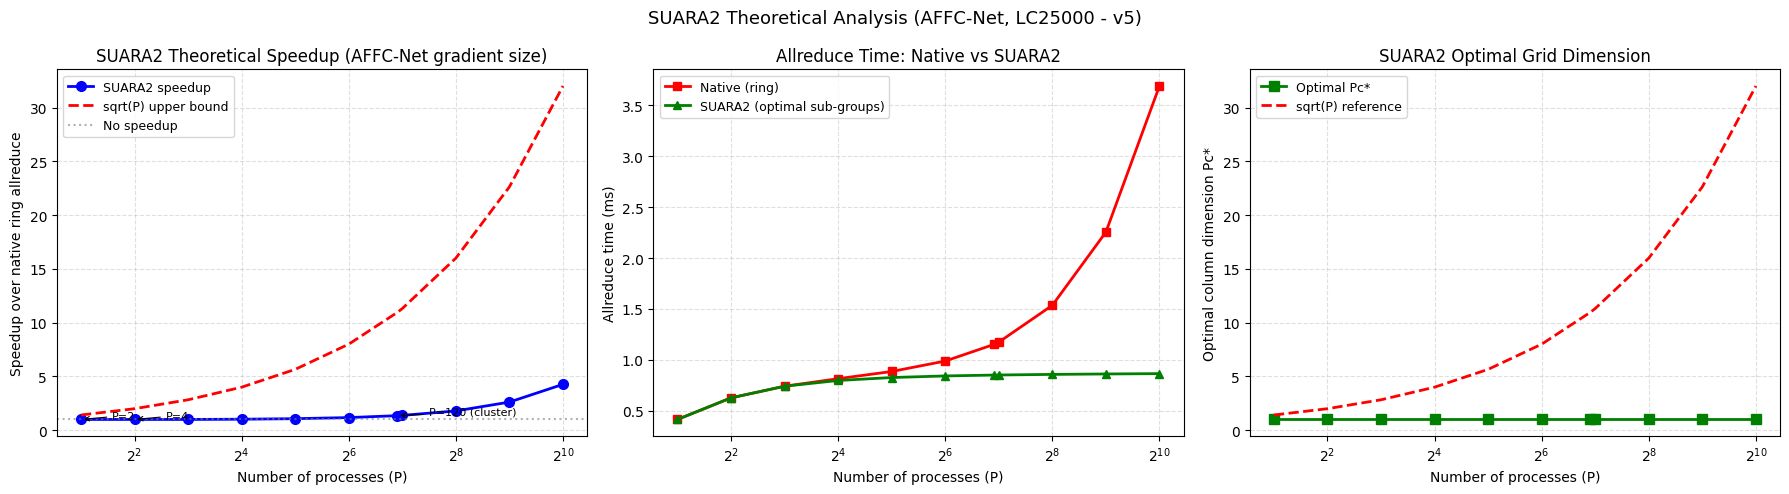

Saved -> /nfsshare/users/P126003189/suara2_theoretical_speedup_v5.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Speedup curve
ax = axes[0]
ax.plot(P_values, speedup_vals, 'bo-', lw=2, markersize=7, label='SUARA2 speedup')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) upper bound')
ax.axhline(1.0, color='gray', ls=':', alpha=0.6, label='No speedup')
for P_mark, label_str in [(2, 'P=2'), (4, 'P=4'), (120, 'P=120 (cluster)')]:
    if P_mark in P_values:
        idx = P_values.index(P_mark)
        ax.annotate(label_str, xy=(P_mark, speedup_vals[idx]),
                    xytext=(P_mark * 1.5, speedup_vals[idx] + 0.08),
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Speedup over native ring allreduce')
ax.set_title('SUARA2 Theoretical Speedup (AFFC-Net gradient size)')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot B: Allreduce times
ax = axes[1]
ax.plot(P_values, t_native_vals, 'rs-', lw=2, markersize=6, label='Native (ring)')
ax.plot(P_values, t_suara_vals,  'g^-', lw=2, markersize=6, label='SUARA2 (optimal sub-groups)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Allreduce time (ms)')
ax.set_title('Allreduce Time: Native vs SUARA2')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot C: Optimal Pc*
ax = axes[2]
ax.plot(P_values, Pc_vals, 'gs-', lw=2, markersize=7, label='Optimal Pc*')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) reference')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Optimal column dimension Pc*')
ax.set_title('SUARA2 Optimal Grid Dimension')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

plt.suptitle('SUARA2 Theoretical Analysis (AFFC-Net, LC25000 - v5)', fontsize=13)
plt.tight_layout()
save_path = os.path.join(HOME, 'suara2_theoretical_speedup_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')


## 4. Training Commands (v5 script)


In [5]:
# Run these in your cluster terminal using train_affcnet_suara_v5.py
#
# P=1 baseline (no distributed)
# CUDA_VISIBLE_DEVICES=0 python ~/train_affcnet_suara_v5.py --mode native --epochs 60 --no_dist
#
# P=2 native
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_v5.py --mode native --epochs 60
#
# P=4 native
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_v5.py --mode native --epochs 60
#
# P=2 SUARA2
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_v5.py --mode suara --epochs 60
#
# P=4 SUARA2
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_v5.py --mode suara --epochs 60

print('Commands listed. Run on the cluster, then proceed to Cell 5.')


Commands listed. Run on the cluster, then proceed to Cell 5.


## 5. Load Results


In [6]:
results = {}
PAPER_TARGET = {'accuracy': 0.9984, 'precision': 0.9984,
                'recall':   0.9984, 'specificity': 0.9996, 'f1': 0.9984}

for mode in ['native', 'suara']:
    for p in [1, 2, 4]:
        for ver in ['ver5', 'ver4', 'ver3']:
            fname = os.path.join(HOME, f'results_{ver}_{mode}_P{p}.json')
            if os.path.exists(fname):
                with open(fname) as f:
                    results[f'{mode}_P{p}'] = json.load(f)
                print(f'Loaded ({ver}): {fname}')
                break
        else:
            print(f'Missing: results_ver5_{mode}_P{p}.json')

print(f'Available configs: {list(results.keys())}')

# Update MS_BYTES from actual gradient size if available
if 'native_P1' in results and 'grad_bytes' in results['native_P1']:
    MS_BYTES = results['native_P1']['grad_bytes']
    print(f'Updated MS_BYTES: {MS_BYTES/1024:.1f} KB')


Loaded (ver5): /nfsshare/users/P126003189/results_ver5_native_P1.json
Loaded (ver5): /nfsshare/users/P126003189/results_ver5_native_P2.json
Loaded (ver5): /nfsshare/users/P126003189/results_ver5_native_P4.json
Missing: results_ver5_suara_P1.json
Loaded (ver5): /nfsshare/users/P126003189/results_ver5_suara_P2.json
Loaded (ver5): /nfsshare/users/P126003189/results_ver5_suara_P4.json
Available configs: ['native_P1', 'native_P2', 'native_P4', 'suara_P2', 'suara_P4']
Updated MS_BYTES: 7130.5 KB


## 6. Classification Metrics + Training Efficiency Table


In [7]:
METRIC_KEYS   = ['acc', 'prec', 'recall', 'spec', 'f1']
METRIC_LABELS = ['Acc', 'Prec', 'Rec',    'Spec', 'F1']

print('=' * 90)
print('Part A  Classification Metrics')
print('=' * 90)
print(f"{'Config':<28} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'Spec':>8} {'F1':>8}")
print('-' * 90)

ROWS = [
    ('AFFC-Net (native, P=1)',  'native_P1'),
    ('AFFC-Net (native, P=2)',  'native_P2'),
    ('AFFC-Net (native, P=4)',  'native_P4'),
    ('AFFC + SUARA2  (P=2)',    'suara_P2'),
    ('AFFC + SUARA2  (P=4)',    'suara_P4'),
]
for label, key in ROWS:
    if key in results:
        r    = results[key]
        vals = [r[f'test_{m}'] * 100 for m in METRIC_KEYS]
        print(f"{label:<28} " + '  '.join(f"{v:>7.2f}%" for v in vals))
    else:
        print(f"{label:<28}  -- not yet run")

paper_vals = [PAPER_TARGET[k] * 100
              for k in ['accuracy','precision','recall','specificity','f1']]
print(f"{'Paper target (AFFC-Net)':<28} " + '  '.join(f"{v:>7.2f}%" for v in paper_vals))
print('=' * 90)

print()
print('=' * 65)
print('Part B  Training Efficiency  — Epoch Wall-Time')
print('=' * 65)
print(f"{'Config':<24} {'avg epoch(s)':>13} {'EP speedup':>11}")
print('-' * 50)

base_ep = results.get('native_P1', {}).get('avg_epoch_time')

for p in [1, 2, 4]:
    for mode in ['native', 'suara']:
        key = f'{mode}_P{p}'
        if p == 1 and mode == 'suara':
            continue
        if key not in results:
            continue
        r = results[key]
        ep_sp = f"{base_ep / r['avg_epoch_time']:.2f}x" if base_ep else '--'
        print(f"{key:<24} {r['avg_epoch_time']:>13.2f} {ep_sp:>11}")

print('=' * 65)
print('  EP speedup: relative to native P=1 baseline')

Part A  Classification Metrics
Config                            Acc     Prec      Rec     Spec       F1
------------------------------------------------------------------------------------------
AFFC-Net (native, P=1)         96.45%    96.50%    96.45%    99.11%    96.45%
AFFC-Net (native, P=2)         96.72%    96.74%    96.72%    99.18%    96.72%
AFFC-Net (native, P=4)         96.45%    96.46%    96.45%    99.11%    96.45%
AFFC + SUARA2  (P=2)           97.01%    97.02%    97.01%    99.25%    97.01%
AFFC + SUARA2  (P=4)           97.09%    97.10%    97.09%    99.27%    97.09%
Paper target (AFFC-Net)        99.84%    99.84%    99.84%    99.96%    99.84%

Part B  Training Efficiency  — Epoch Wall-Time
Config                    avg epoch(s)  EP speedup
--------------------------------------------------
native_P1                        58.48       1.00x
native_P2                        60.84       0.96x
suara_P2                         46.43       1.26x
native_P4                        

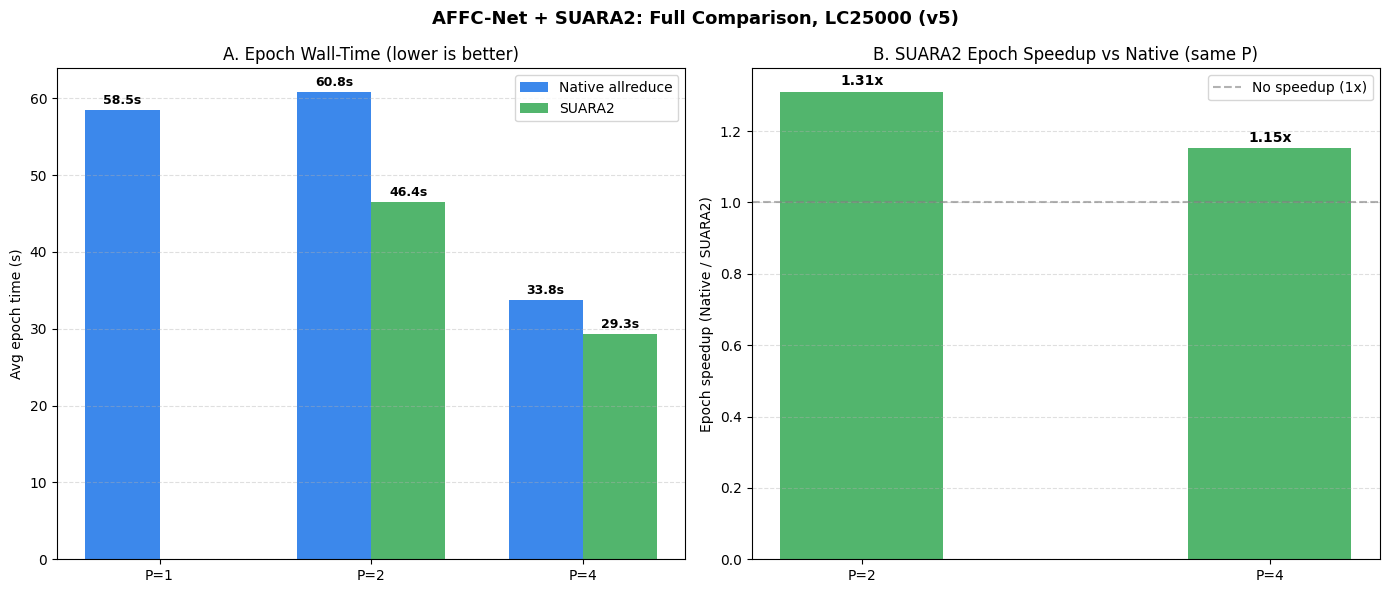

Saved -> /nfsshare/users/P126003189/suara2_final_comparison_v5.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart A: Epoch wall-time
ax = axes[0]
p_vals = [1, 2, 4]
ep_nat = [results.get(f'native_P{p}', {}).get('avg_epoch_time') for p in p_vals]
ep_sua = [None] + [results.get(f'suara_P{p}', {}).get('avg_epoch_time') for p in [2, 4]]
x = np.arange(len(p_vals)); w = 0.35
b1 = ax.bar(x - w/2, [v if v else 0 for v in ep_nat], w,
            label='Native allreduce', color='#1a73e8', alpha=0.85)
b2 = ax.bar(x + w/2, [v if v else 0 for v in ep_sua], w,
            label='SUARA2', color='#34a853', alpha=0.85)
for bar, val in list(zip(b1, ep_nat)) + list(zip(b2, ep_sua)):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'P={p}' for p in p_vals])
ax.set_ylabel('Avg epoch time (s)')
ax.set_title('A. Epoch Wall-Time (lower is better)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

# Chart B: Epoch speedup (SUARA2 vs Native, same P)
ax = axes[1]
p_comp = [2, 4]
ep_speedups = []
for p in p_comp:
    nat = results.get(f'native_P{p}', {}).get('avg_epoch_time')
    sua = results.get(f'suara_P{p}',  {}).get('avg_epoch_time')
    ep_speedups.append(nat / sua if nat and sua else 0)

x2 = np.arange(len(p_comp))
bars = ax.bar(x2, ep_speedups, color='#34a853', alpha=0.85, width=0.4)
ax.axhline(1.0, color='gray', ls='--', alpha=0.6, label='No speedup (1x)')
for bar, val in zip(bars, ep_speedups):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels([f'P={p}' for p in p_comp])
ax.set_ylabel('Epoch speedup (Native / SUARA2)')
ax.set_title('B. SUARA2 Epoch Speedup vs Native (same P)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

plt.suptitle('AFFC-Net + SUARA2: Full Comparison, LC25000 (v5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(HOME, 'suara2_final_comparison_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')

In [9]:
print('\n' + '=' * 72)
print('EXPERIMENT SUMMARY -- AFFC-Net + SUARA2 (v5)')
print('=' * 72)

if 'native_P1' in results:
    r1 = results['native_P1']
    print('\nAFFC-Net Baseline (P=1, single GPU):')
    for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
        print(f'  {ml:<14}: {r1["test_" + mk]*100:.2f}%')
    print(f"  Epoch time  : {r1['avg_epoch_time']:.2f}s")
    if 'grad_bytes' in r1:
        print(f"  Grad buffer : {r1['grad_bytes']/1024:.1f} KB")

configs = [('native_P2','Native P=2'),('native_P4','Native P=4'),
           ('suara_P2', 'SUARA2 P=2'),('suara_P4', 'SUARA2 P=4')]
for cfg_key, cfg_label in configs:
    if cfg_key in results:
        r = results[cfg_key]
        print(f'\n{cfg_label}:')
        print(f"  F1={r['test_f1']*100:.2f}%  Acc={r['test_acc']*100:.2f}%  "
              f"epoch={r['avg_epoch_time']:.2f}s")

print('\n' + '-' * 72)
print('Epoch speedup (SUARA2 vs Native, same P):')
base_ep = results.get('native_P1', {}).get('avg_epoch_time')
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        ep_sp = results[nk]['avg_epoch_time'] / results[sk]['avg_epoch_time']
        ep_vs_p1 = base_ep / results[sk]['avg_epoch_time'] if base_ep else None
        p1_str = f"  vs P=1 baseline: {ep_vs_p1:.2f}x" if ep_vs_p1 else ""
        print(f'  P={p}: Epoch speedup={ep_sp:.3f}x{p1_str}')
print('=' * 72)


EXPERIMENT SUMMARY -- AFFC-Net + SUARA2 (v5)

AFFC-Net Baseline (P=1, single GPU):
  Acc           : 96.45%
  Prec          : 96.50%
  Rec           : 96.45%
  Spec          : 99.11%
  F1            : 96.45%
  Epoch time  : 58.48s
  Grad buffer : 7130.5 KB

Native P=2:
  F1=96.72%  Acc=96.72%  epoch=60.84s

Native P=4:
  F1=96.45%  Acc=96.45%  epoch=33.78s

SUARA2 P=2:
  F1=97.01%  Acc=97.01%  epoch=46.43s

SUARA2 P=4:
  F1=97.09%  Acc=97.09%  epoch=29.33s

------------------------------------------------------------------------
Epoch speedup (SUARA2 vs Native, same P):
  P=2: Epoch speedup=1.310x  vs P=1 baseline: 1.26x
  P=4: Epoch speedup=1.152x  vs P=1 baseline: 1.99x
